<a href="https://colab.research.google.com/github/Moysezg/financial-risk-management-var-models/blob/main/02_historical_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Descargando datos para VITROA.MX...


/tmp/ipykernel_174/3382407158.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval=periodicidad)
[*********************100%***********************]  1 of 1 completed


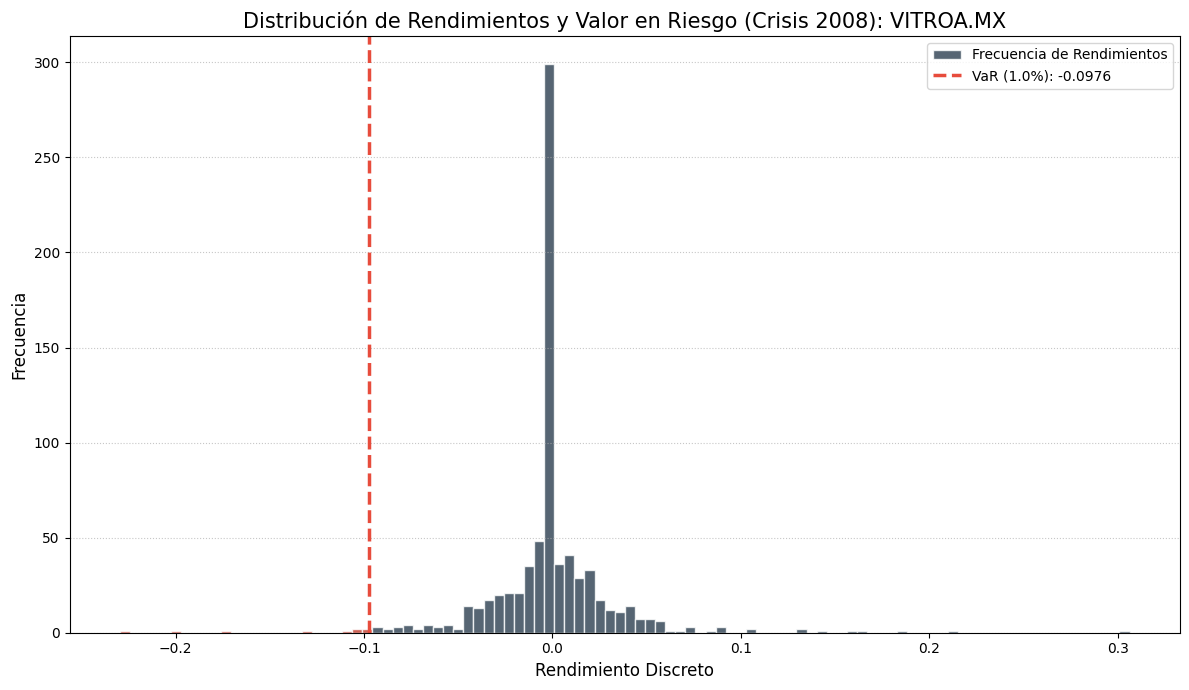

--------------------------------------------------------------------------------
Activo: VITROA.MX | Periodo: 2007-01-01 a 2009-12-31 | Periodicidad: 1d | Percentil (1.0%): -0.097620
--------------------------------------------------------------------------------


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# PARÁMETROS DE CONFIGURACIÓN
# =============================================================================
ticker = "VITROA.MX"          # Símbolo de Vitro en la BMV
periodicidad = "1d"           # Frecuencia diaria
particiones = 100             # Resolución del histograma
confianza = 0.01              # Nivel de confianza al 1% (Percentil 1)

# Fechas fijas para capturar la crisis de derivados (2007-2009)
fecha_inicio = "2007-01-01"
fecha_fin    = "2009-12-31"

# =============================================================================
# PIPELINE DE PROCESAMIENTO
# =============================================================================

# 1. Obtención de datos
print(f"Descargando datos para {ticker}...")
df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval=periodicidad)

if df.empty:
    print("Error: No se obtuvieron datos. Verifique el ticker o la conexión.")
else:
    # 2. Generación de rendimientos discretos
    # Usamos 'Close' para el cálculo de variaciones porcentuales
    precios = df['Close']
    rendimientos = precios.pct_change().dropna()

    # 3. Cálculo del Valor en Riesgo (VaR) Histórico
    # Se extrae el valor escalar con .iloc[0] para evitar errores de series
    var_historico = rendimientos.quantile(confianza)
    var_valor = var_historico.iloc[0] if isinstance(var_historico, pd.Series) else var_historico

    # 4. Visualización y Graficación
    plt.figure(figsize=(12, 7))

    # Histograma de la distribución
    n, bins, patches = plt.hist(rendimientos, bins=particiones, color='#2c3e50',
                                edgecolor='white', alpha=0.8, label='Frecuencia de Rendimientos')

    # Marcado del percentil (VaR)
    plt.axvline(var_valor, color='#e74c3c', linestyle='--', linewidth=2.5,
                label=f'VaR ({confianza*100:.1f}%): {var_valor:.4f}')

    # Estética del gráfico
    plt.title(f'Distribución de Rendimientos y Valor en Riesgo (Crisis 2008): {ticker}', fontsize=15)
    plt.xlabel('Rendimiento Discreto', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')

    # Sombreado del área de riesgo (cola izquierda)
    for i in range(len(patches)):
        if bins[i] < var_valor:
            patches[i].set_facecolor('#c0392b')

    plt.tight_layout()
    plt.show()

    # 5. Línea informativa final
    print("-" * 80)
    print(f"Activo: {ticker} | Periodo: {fecha_inicio} a {fecha_fin} | "
          f"Periodicidad: {periodicidad} | Percentil ({confianza*100:.1f}%): {var_valor:.6f}")
    print("-" * 80)

<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:90: SyntaxWarning: invalid escape sequence '\l'
<>:93: SyntaxWarning: invalid escape sequence '\l'
<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:90: SyntaxWarning: invalid escape sequence '\l'
<>:93: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_174/1651579672.py:83: SyntaxWarning: invalid escape sequence '\l'
  label=f'Decaimiento GARCH ($\lambda$={lam_garch:.4f})', density=True)
/tmp/ipykernel_174/1651579672.py:90: SyntaxWarning: invalid escape sequence '\l'
  label=f'VaR Exponencial ($\lambda$=0.98): {var_exponencial:.4f}')
/tmp/ipykernel_174/1651579672.py:93: SyntaxWarning: invalid escape sequence '\l'
  label=f'VaR GARCH ($\lambda$={lam_garch:.4f}): {var_garch:.4f}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 31.5 MB/s eta 0:00:00


/tmp/ipykernel_174/1651579672.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval=periodicidad)
[*********************100%***********************]  1 of 1 completed

Descargando datos para VITROA.MX...


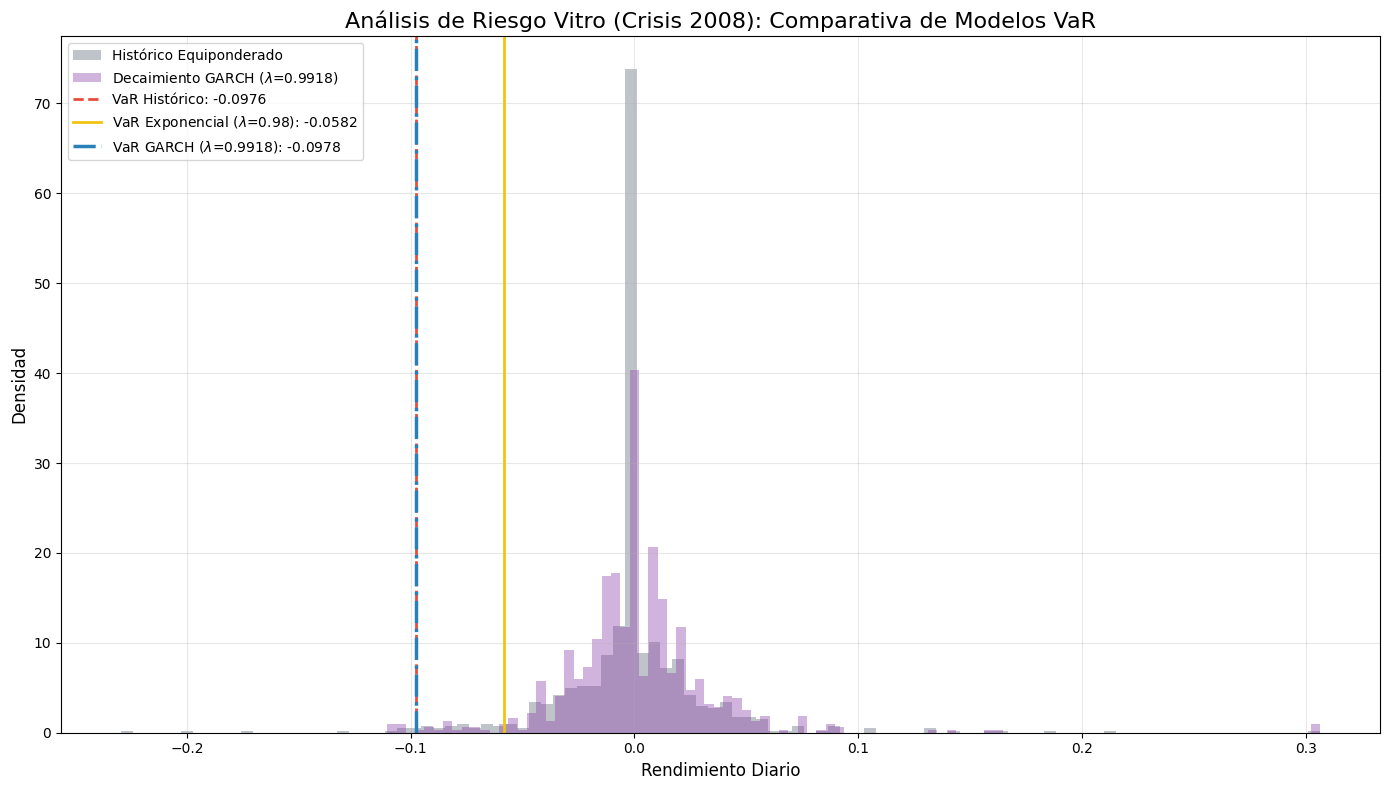

--------------------------------------------------------------------------------------------------------------
ANÁLISIS DE RIESGO: VITROA.MX | FECHAS: 2007-01-01 a 2009-12-31
VaR Histórico (1%):   -0.097620
VaR Exponencial (1%): -0.058209
VaR GARCH (1%):       -0.097826
Persistencia GARCH (Alpha + Beta): 0.9918
--------------------------------------------------------------------------------------------------------------


In [ ]:
!pip install arch
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from arch import arch_model

# =============================================================================
# 1. PARÁMETROS DE CONFIGURACIÓN
# =============================================================================
ticker = "VITROA.MX"
periodicidad = "1d"
particiones = 100
confianza = 0.01
lam_fixed = 0.98

# Periodo crítico: Antes y después del colapso de 2008
fecha_inicio = "2007-01-01"
fecha_fin    = "2009-12-31"

# =============================================================================
# 2. OBTENCIÓN Y PREPROCESAMIENTO DE DATOS
# =============================================================================
print(f"Descargando datos para {ticker}...")
df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval=periodicidad)

if df.empty:
    print(f"Error: No se encontraron datos para {ticker}.")
else:
    # Selección de precios de cierre
    precios = df['Close']
    rendimientos = precios.pct_change().dropna()

    # Limpieza de datos (asegurar que sea una serie unidimensional)
    if isinstance(rendimientos, pd.DataFrame):
        rendimientos = rendimientos.iloc[:, 0]

    n_obs = len(rendimientos)

    # =============================================================================
    # 3. CÁLCULO DE VaR: HISTÓRICO, EXPONENCIAL Y GARCH
    # =============================================================================

    # A) VaR Histórico Equiponderado (Simple)
    var_historico = rendimientos.quantile(confianza)

    # B) VaR Exponencial (Lambda fijo = 0.98)
    pesos_exp = np.array([lam_fixed**(n_obs - i - 1) for i in range(n_obs)])
    pesos_exp /= pesos_exp.sum()
    df_exp = pd.DataFrame({'ret': rendimientos.values, 'w': pesos_exp}).sort_values(by='ret')
    df_exp['w_acum'] = df_exp['w'].cumsum()
    var_exponencial = df_exp[df_exp['w_acum'] >= confianza]['ret'].iloc[0]

    # C) VaR GARCH(1,1)
    modelo_garch = arch_model(rendimientos * 100, vol='Garch', p=1, q=1, dist='Normal')
    res = modelo_garch.fit(disp='off')

    alpha = res.params['alpha[1]']
    beta = res.params['beta[1]']
    lam_garch = alpha + beta

    if lam_garch >= 1:
        lam_garch = 0.999

    pesos_garch = np.array([lam_garch**(n_obs - i - 1) for i in range(n_obs)])
    pesos_garch /= pesos_garch.sum()
    df_garch = pd.DataFrame({'ret': rendimientos.values, 'w': pesos_garch}).sort_values(by='ret')
    df_garch['w_acum'] = df_garch['w'].cumsum()
    var_garch = df_garch[df_garch['w_acum'] >= confianza]['ret'].iloc[0]

    # =============================================================================
    # 4. VISUALIZACIÓN COMPARATIVA
    # =============================================================================
    plt.figure(figsize=(14, 8))

    # Histograma Histórico
    plt.hist(rendimientos, bins=particiones, color='#2c3e50', alpha=0.3,
             label='Histórico Equiponderado', density=True)

    # Histograma GARCH
    rend_garch_sample = np.random.choice(rendimientos.values, size=n_obs, p=pesos_garch)
    plt.hist(rend_garch_sample, bins=particiones, color='#8e44ad', alpha=0.4,
             label=f'Decaimiento GARCH ($\lambda$={lam_garch:.4f})', density=True)

    # Líneas de VaR - Corregidas para evitar errores de f-string
    plt.axvline(var_historico, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'VaR Histórico: {var_historico:.4f}')

    plt.axvline(var_exponencial, color='#f1c40f', linestyle='-', linewidth=2,
                label=f'VaR Exponencial ($\lambda$=0.98): {var_exponencial:.4f}')

    plt.axvline(var_garch, color='#2980b9', linestyle='-.', linewidth=2.5,
                label=f'VaR GARCH ($\lambda$={lam_garch:.4f}): {var_garch:.4f}')

    plt.title(f'Análisis de Riesgo Vitro (Crisis 2008): Comparativa de Modelos VaR', fontsize=16)
    plt.xlabel('Rendimiento Diario', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =============================================================================
    # 5. RESULTADOS FINALES
    # =============================================================================
    print("-" * 110)
    print(f"ANÁLISIS DE RIESGO: {ticker} | FECHAS: {fecha_inicio} a {fecha_fin}")
    print(f"VaR Histórico (1%):   {var_historico:.6f}")
    print(f"VaR Exponencial (1%): {var_exponencial:.6f}")
    print(f"VaR GARCH (1%):       {var_garch:.6f}")
    print(f"Persistencia GARCH (Alpha + Beta): {lam_garch:.4f}")
    print("-" * 110)

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import genpareto

def calculate_extreme_jump_var(data, confidence_level=0.99, horizon=1):
    """
    Calcula VaR combinando difusión correlacionada y saltos GPD (POT).
    """
    # 1. Parámetros de Difusión (Normal)
    returns = data.pct_change().dropna()
    mu = returns.mean()
    cov_matrix = returns.cov()
    corr_matrix = returns.corr()
    sigma = returns.std()

    # 2. Ajuste GPD (Percentil 90 como umbral u)
    gpd_params = {}
    for col in returns.columns:
        u = np.percentile(returns[col], 90)
        excesses = returns[col][returns[col] > u] - u

        # Ajuste por Máxima Verosimilitud (MLE)
        shape, loc, scale = genpareto.fit(excesses)
        gpd_params[col] = {'shape': shape, 'scale': scale, 'threshold': u}

    # 3. Intensidad de Poisson (Lambda)
    # Definimos salto como exceso del percentil 90
    lambdas = (returns > returns.quantile(0.90)).mean()

    # 4. Simulación Monte Carlo para VaR
    n_sims = 100000
    n_assets = len(returns.columns)

    # Difusión correlacionada (Cholesky)
    L = np.linalg.cholesky(cov_matrix)
    Z = np.random.normal(0, 1, (n_assets, n_sims))
    diffusion = (L @ Z).T

    # Componente de Salto (Poisson + GPD)
    jumps = np.zeros((n_sims, n_assets))
    for i, col in enumerate(returns.columns):
        # ¿Ocurre salto? (Poisson)
        poisson_events = np.random.poisson(lambdas[i], n_sims)

        # Si ocurre, magnitud de la GPD
        mask = poisson_events > 0
        num_jumps = np.sum(mask)
        if num_jumps > 0:
            p = gpd_params[col]
            # Activación de la GPD
            jump_magnitudes = genpareto.rvs(p['shape'], loc=0, scale=p['scale'], size=num_jumps)
            jumps[mask, i] = p['threshold'] + jump_magnitudes

    # Rendimiento Total = Normal + Salto
    total_returns = diffusion + jumps

    # VaR de la Cartera (Pesos iguales por simplicidad)
    portfolio_returns = total_returns.mean(axis=1)
    var = np.percentile(portfolio_returns, (1 - confidence_level) * 100)

    # Matriz de Parámetros
    param_matrix = pd.DataFrame({
        'Mu': mu,
        'Sigma': sigma,
        'Lambda (Poisson)': lambdas,
        'GPD_Shape (Xi)': [gpd_params[c]['shape'] for c in returns.columns],
        'GPD_Scale (Sigma_u)': [gpd_params[c]['scale'] for c in returns.columns]
    })

    return var, param_matrix

# Ejemplo de uso con datos dummy
# data = pd.DataFrame(...)
# var, params = calculate_extreme_jump_var(data)